In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_path = "../data/processed/south_german_credit_clean.csv"

In [3]:
import os

os.path.exists(data_path)

True

In [4]:
df = pd.read_csv(data_path)

In [5]:
df.shape

(1000, 21)

In [6]:
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [7]:
df["credit_risk"].value_counts()

credit_risk
1    700
0    300
Name: count, dtype: int64

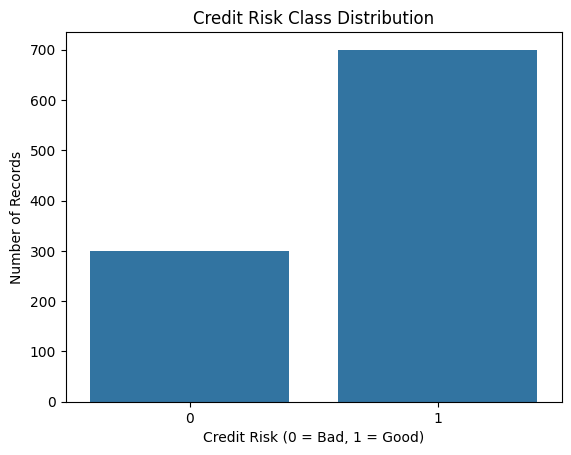

In [8]:
sns.countplot(data=df, x="credit_risk")
plt.title("Credit Risk Class Distribution")
plt.xlabel("Credit Risk (0 = Bad, 1 = Good)")
plt.ylabel("Number of Records")
plt.show()

Bu grafikte veri setindeki iyi ve kötü kredi sayıları görülüyor. Veri setinde 700 tane iyi kredi, 300 tane kötü kredi var. Yani iyi kredi sayısı kötü kredi sayısından daha fazla. Bu yüzden ileride model kurarken sadece genel doğruluk oranına bakmak yeterli olmayabilir. Çünkü model kötü kredileri iyi tahmin edemezse kredi riski açısından sorun oluşabilir.

In [9]:
df["age"].describe()

count    1000.00000
mean       35.54200
std        11.35267
min        19.00000
25%        27.00000
50%        33.00000
75%        42.00000
max        75.00000
Name: age, dtype: float64

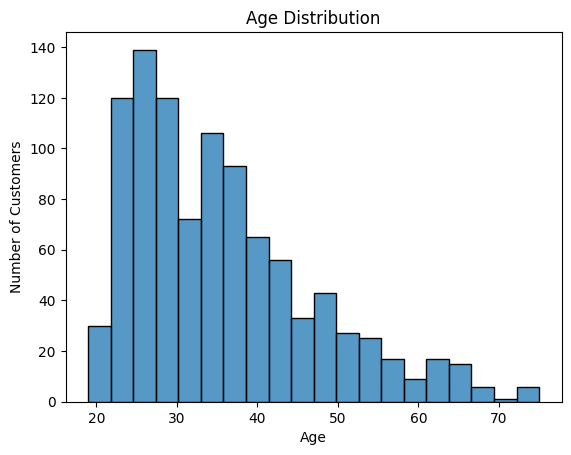

In [10]:
sns.histplot(data=df, x="age", bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

Bu grafikte müşterilerin yaş dağılımı görülüyor. Müşterilerin büyük kısmı 20-40 yaş aralığında toplanmış. Özellikle 25-35 yaş aralığında daha fazla müşteri var gibi görünüyor. Yaş yükseldikçe müşteri sayısı genel olarak azalıyor.

In [11]:
df["amount"].describe()

count     1000.00000
mean      3271.24800
std       2822.75176
min        250.00000
25%       1365.50000
50%       2319.50000
75%       3972.25000
max      18424.00000
Name: amount, dtype: float64

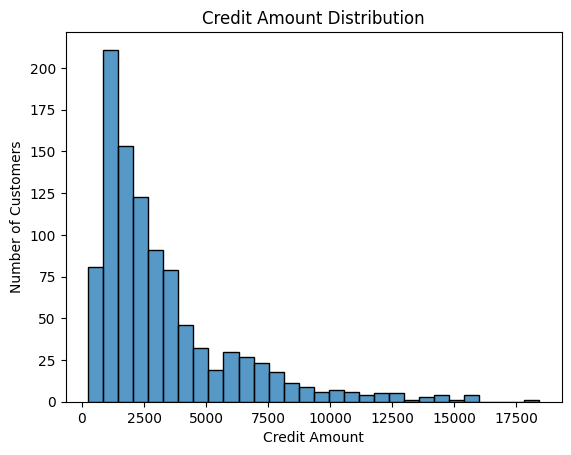

In [12]:
sns.histplot(data=df, x="amount", bins=30)
plt.title("Credit Amount Distribution")
plt.xlabel("Credit Amount")
plt.ylabel("Number of Customers")
plt.show()

Bu grafikte kredi miktarlarının dağılımı görülüyor. Kredilerin büyük kısmı düşük ve orta miktarlarda toplanmış. Özellikle 1000-4000 aralığında daha fazla kredi var gibi görünüyor. Çok yüksek kredi miktarları ise daha az sayıda olduğu için grafik sağa doğru uzamış.Yani dağılım sağa çarpık görünüyor.

In [13]:
df["duration"].describe()

count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: duration, dtype: float64

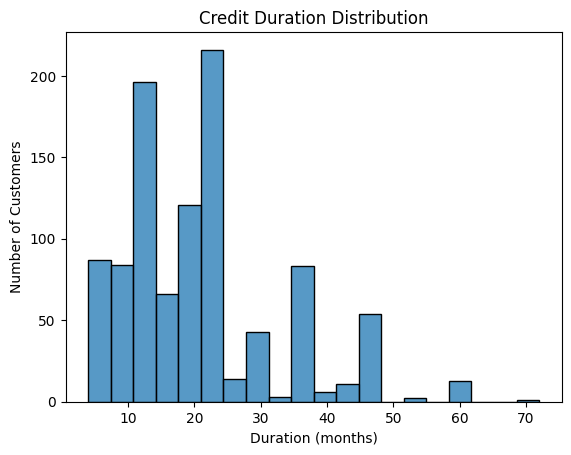

In [14]:
sns.histplot(data=df, x="duration", bins=20)
plt.title("Credit Duration Distribution")
plt.xlabel("Duration (months)")
plt.ylabel("Number of Customers")
plt.show()

Bu grafikte kredi sürelerinin genel dağılımı görülüyor. Grafiğe göre krediler daha çok kısa ve orta vadelerde toplanmış gibi görünüyor. Histogram aralıklı gösterdiği için tek tek ay değerlerini sadece grafikten kesin söylemek zor olabilir. Bu yüzden sürelerin sayısal dağılımına da baktım. Sayısal olarak en sık görülen süreler 24 ay, 12 ay ve 18 ay olarak görünüyor. Daha uzun vadeli krediler ise veri setinde daha az sayıda bulunuyor.

In [15]:
df["duration"].value_counts().sort_index()

duration
4       6
5       1
6      75
7       5
8       7
9      49
10     28
11      9
12    179
13      4
14      4
15     64
16      2
18    113
20      8
21     30
22      2
24    184
26      1
27     13
28      3
30     40
33      3
36     83
39      5
40      1
42     11
45      5
47      1
48     48
54      2
60     13
72      1
Name: count, dtype: int64

In [16]:
df.groupby("credit_risk")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
credit_risk,,,,,,,,
0,300.0,3938.126667,3535.818955,433.0,1352.5,2574.5,5141.50,18424.0
1,700.0,2985.442857,2401.495579,250.0,1375.5,2244.0,3634.75,15857.0


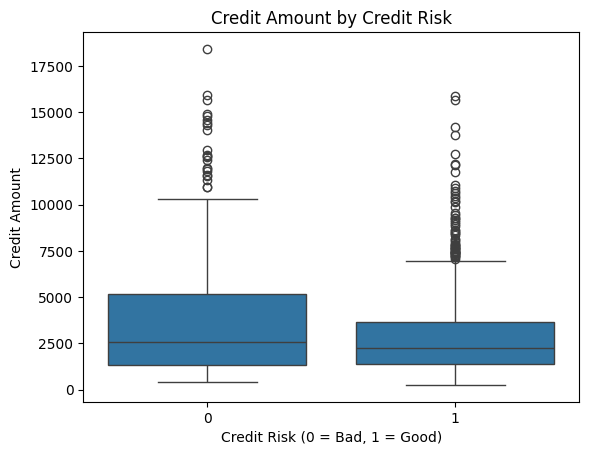

In [17]:
sns.boxplot(data=df, x="credit_risk", y="amount")
plt.title("Credit Amount by Credit Risk")
plt.xlabel("Credit Risk (0 = Bad, 1 = Good)")
plt.ylabel("Credit Amount")
plt.show()

Bu grafikte kredi miktarları iyi ve kötü kredi gruplarına göre karşılaştırılıyor. Kötü kredi grubunda kredi miktarlarının genel olarak biraz daha yüksek ve daha dağınık olduğu görülüyor. İyi kredi grubunda ise kredi miktarları daha düşük seviyelerde yoğunlaşmış gibi duruyor. Bu durum kredi miktarının risk tahmininde önemli bir değişken olabileceğini düşündürüyor.
Daha yüksek kredi miktarlarında risk artıyor olabilir ama kesin yorum için model sonuçlarına da bakmak gerekir.

In [18]:
df.groupby("credit_risk")["duration"].describe()

,count,mean,std,min,25%,50%,75%,max
credit_risk,,,,,,,,
0,300.0,24.860000,13.282639,6.0,12.0,24.0,36.0,72.0
1,700.0,19.207143,11.079564,4.0,12.0,18.0,24.0,60.0


Kredi süresi uzadıkça risk artıyor olabilir.Bunu grafikle de görelim.

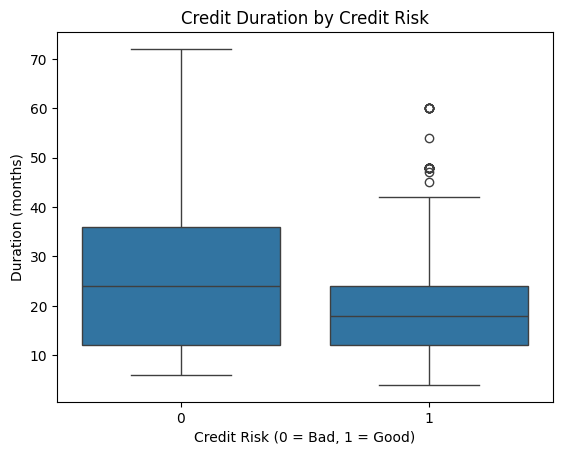

In [19]:
sns.boxplot(data=df, x="credit_risk", y="duration")
plt.title("Credit Duration by Credit Risk")
plt.xlabel("Credit Risk (0 = Bad, 1 = Good)")
plt.ylabel("Duration (months)")
plt.show()

Bu grafikte kredi süresi iyi ve kötü kredi gruplarına göre karşılaştırılıyor. Kötü kredi grubunda kredi sürelerinin genel olarak daha uzun olduğu görülüyor. İyi kredi grubunda ise süreler daha kısa vadelerde toplanmış gibi duruyor. Bu durum kredi süresinin risk tahmininde önemli olabilecek değişkenlerden biri olduğunu düşündürüyor.

Özetle:
amount   → kötü kredi grubunda ortalama daha yüksek görünüyor
duration → kötü kredi grubunda ortalama daha uzun görünüyor

In [20]:
df.groupby("credit_risk")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
credit_risk,,,,,,,,
0,300.0,33.96,11.225199,19.0,25.0,31.0,40.0,74.0
1,700.0,36.22,11.347428,19.0,27.0,34.0,42.0,75.0


İyi kredi grubundaki müşterilerin yaş ortalaması biraz daha yüksek görünüyor.Bu bize şunu düşündürebilir:
Yaş değişkeni kredi riskiyle bir miktar ilişkili olabilir.
Ama fark çok büyük değil.Çünkü 33 ile 36. Bu yüzden kesin yorum yapmadan grafikle de bakalım.

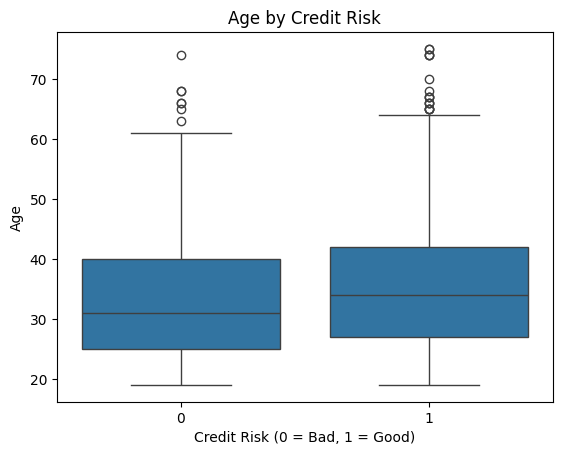

In [21]:
sns.boxplot(data=df, x="credit_risk", y="age")
plt.title("Age by Credit Risk")
plt.xlabel("Credit Risk (0 = Bad, 1 = Good)")
plt.ylabel("Age")
plt.show()

Bu grafikte yaş değişkeni iyi ve kötü kredi gruplarına göre karşılaştırılıyor. İyi kredi grubunda yaş değerleri biraz daha yüksek görünüyor. Kötü kredi grubunda ise yaşlar daha düşük tarafta yoğunlaşmış gibi duruyor. Yine de iki grup tamamen ayrılmış değil, bu yüzden yaş tek başına güçlü bir karar vermek için yeterli olmayabilir.

In [22]:
df["status"].value_counts().sort_index()

status
1    274
2    269
3     63
4    394
Name: count, dtype: int64

1 = no checking account → 274 kişi
2 = negatif bakiye       → 269 kişi
3 = 0-200 DM arası       → 63 kişi
4 = 200 DM ve üzeri      → 394 kişi

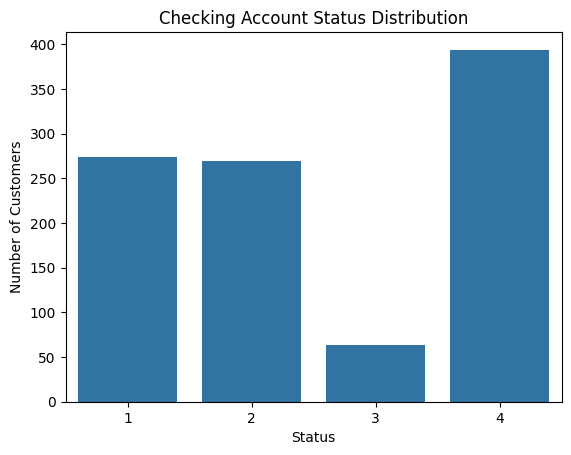

In [23]:
sns.countplot(data=df, x="status")
plt.title("Checking Account Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Customers")
plt.show()

Bu grafikte müşterilerin hesap durumu kategorileri görülüyor. En fazla müşteri status = 4 grubunda yer alıyor. Status = 3 grubu ise diğerlerine göre daha az sayıda. Bu değişken müşterinin hesap durumunu gösterdiği için kredi riskini tahmin ederken önemli olabilir.

In [24]:
pd.crosstab(df["status"], df["credit_risk"])

credit_risk,0,1
status,,
1,135,139
2,105,164
3,14,49
4,46,348


status = 1 grubunda 135 kötü, 139 iyi kredi var.
status = 4 grubunda 46 kötü, 348 iyi kredi var.
Bu bize önemli bir şey gösteriyor:
status = 4 grubunda iyi kredi sayısı çok daha fazla görünüyor.
status = 1 grubunda kötü ve iyi kredi sayıları birbirine yakın.
Ama daha net yorum yapmak için oranlara bakmak daha iyi olur.
kötü kredi oranı = kötü kredi sayısı / toplam kişi sayısı

In [25]:
status_risk_table = pd.crosstab(df["status"], df["credit_risk"], normalize="index") * 100
status_risk_table

credit_risk,0,1
status,,
1,49.270073,50.729927
2,39.033457,60.966543
3,22.222222,77.777778
4,11.675127,88.324873


status = 1 → %49 kötü kredi
status = 2 → %39 kötü kredi
status = 3 → %22 kötü kredi
status = 4 → %12 kötü kredi
Bu çok önemli bulgulardan biri olabilir. Çünkü hesap durumu ile kredi riski arasında belirgin bir ilişki görünüyor:
Status değeri iyileştikçe kötü kredi oranı azalıyor gibi görünüyor.

Özet:
Veri setinde iyi kredi sayısı kötü kredi sayısından fazla.
Kötü kredi grubunda kredi miktarı ortalama olarak daha yüksek görünüyor.
Kötü kredi grubunda kredi süresi ortalama olarak daha uzun görünüyor.
İyi kredi grubunda yaş ortalaması biraz daha yüksek.
Status değişkeni riskle belirgin ilişkili görünüyor.

In [26]:
df["savings"].value_counts().sort_index()

savings
1    603
2    103
3     63
4     48
5    183
Name: count, dtype: int64

codetable.txt dosyasına göre:
savings:
1 = unknown / no savings account
2 = less than 100 DM
3 = 100 - 500 DM
4 = 500 - 1000 DM
5 = 1000 DM or more
savings, müşterinin tasarruf / birikim hesabı durumunu gösterir. Kredi riski açısından önemli olabilir çünkü birikimi olan müşterinin geri ödeme gücü daha iyi olabilir.
1 = unknown / no savings account → 603 kişi
2 = less than 100 DM             → 103 kişi
3 = 100 - 500 DM                 → 63 kişi
4 = 500 - 1000 DM                → 48 kişi
5 = 1000 DM or more              → 183 kişi
Yani veri setinde en büyük grup:
savings = 1
Bu grup, birikim hesabı bilinmeyen veya olmayan müşterileri gösteriyor.

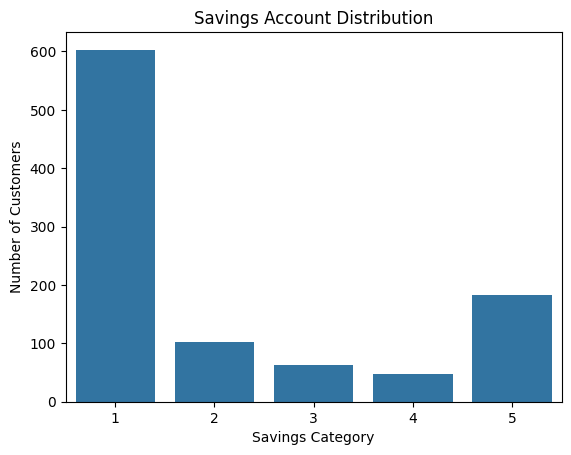

In [27]:
sns.countplot(data=df, x="savings")
plt.title("Savings Account Distribution")
plt.xlabel("Savings Category")
plt.ylabel("Number of Customers")
plt.show()

Bu grafikte müşterilerin birikim hesabı durumları görülüyor. En fazla müşteri savings = 1 grubunda yer alıyor. Bu grup, birikim hesabı bilinmeyen veya olmayan müşterileri temsil ediyor. Savings = 5 grubu da diğer bazı gruplara göre daha fazla görünüyor. Bu değişken müşterinin finansal durumuyla ilgili bilgi verdiği için kredi riski açısından önemli olabilir.

In [28]:
savings_risk_table = pd.crosstab(df["savings"], df["credit_risk"], normalize="index") * 100
savings_risk_table

credit_risk,0,1
savings,,
1,35.986733,64.013267
2,33.009709,66.990291
3,17.460317,82.539683
4,12.500000,87.500000
5,17.486339,82.513661


savings = 1 → %36 kötü kredi
savings = 2 → %33 kötü kredi
savings = 3 → %17 kötü kredi
savings = 4 → %12.5 kötü kredi
savings = 5 → %17.5 kötü kredi
Bu tabloda her savings grubu için kötü ve iyi kredi oranları görülüyor. Savings = 1 ve savings = 2 gruplarında kötü kredi oranı daha yüksek görünüyor. Daha yüksek birikim kategorilerinde ise kötü kredi oranı genel olarak daha düşük.
Bu yüzden savings değişkeni kredi riskini tahmin ederken işe yarayabilecek bir değişken olabilir.

Sonrakinde credit_history, müşterinin geçmiş kredi ödeme davranışını gösterir. Kredi riski için çok önemli bir değişken olabilir.

codetable.txt dosyasına göre:

credit_history:
0 = geçmişte ödeme gecikmesi var
1 = kritik hesap / başka yerde kredi var
2 = kredi alınmamış veya tüm krediler düzgün ödenmiş
3 = mevcut krediler şimdiye kadar düzgün ödenmiş
4 = bu bankadaki tüm krediler düzgün ödenmiş

In [29]:
df["credit_history"].value_counts().sort_index()

credit_history
0     40
1     49
2    530
3     88
4    293
Name: count, dtype: int64

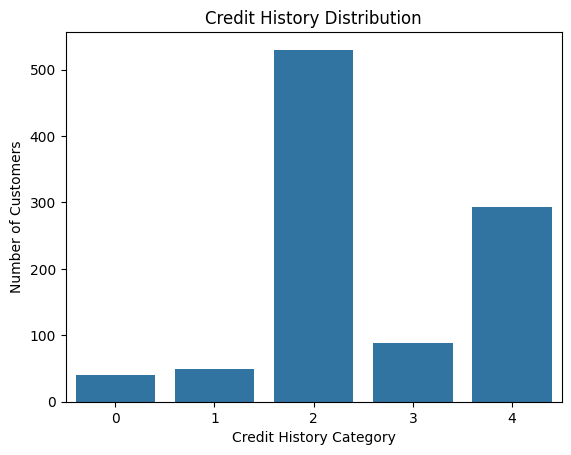

In [30]:
sns.countplot(data=df, x="credit_history")
plt.title("Credit History Distribution")
plt.xlabel("Credit History Category")
plt.ylabel("Number of Customers")
plt.show()

Bu grafikte müşterilerin kredi geçmişi kategorileri görülüyor. En fazla müşteri credit_history = 2 grubunda yer alıyor. Credit_history = 4 grubu da yüksek sayıda görünüyor. Credit_history = 0 ve 1 grupları ise daha az sayıda. Kredi geçmişi müşterinin önceki ödeme davranışıyla ilgili olduğu için risk tahmininde önemli bir değişken olabilir.

In [31]:
credit_history_risk_table = pd.crosstab(df["credit_history"], df["credit_risk"], normalize="index") * 100
credit_history_risk_table

credit_risk,0,1
credit_history,,
0,62.500000,37.500000
1,57.142857,42.857143
2,31.886792,68.113208
3,31.818182,68.181818
4,17.064846,82.935154


credit_history = 0 → %62.5 kötü kredi
credit_history = 1 → %57.1 kötü kredi
credit_history = 2 → %31.9 kötü kredi
credit_history = 3 → %31.8 kötü kredi
credit_history = 4 → %17.1 kötü kredi
Kredi geçmişi daha iyi olan gruplarda kötü kredi oranı daha düşük görünüyor.